<a href="https://colab.research.google.com/github/bhoomikanegi/Design-and-Analysis-Assignments/blob/main/DAA_Lab_Asgmt_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install memory_profiler

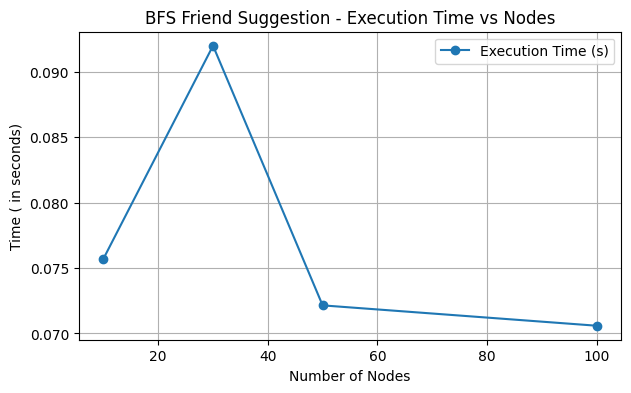

Friend suggestions for A: ['D', 'E', 'F']
Execution Time = 0.07893s, Memory Used = 0.0000 MB

Analysis & Impact:
• BFS runs in O(V + E) and scales linearly.
• Ideal for mutual friend discovery in large networks.
• Visualization shows social reach and connection strength.


In [4]:
# Problem 1: Social Network Friend Suggestion (BFS)

import time
from collections import defaultdict, deque
from memory_profiler import memory_usage
import matplotlib.pyplot as plt
import networkx as nx
import random

def construct_graph(edges):
    g = defaultdict(list)
    for u, v in edges:
        g[u].append(v)
        g[v].append(u)
    return g

def friends_suggestion_bfs(graph, user):
    visited = set([user])
    queue = deque([(user, 0)])
    direct = set(graph[user])
    suggestions = set()
    while queue:
        node, depth = queue.popleft()
        if depth >= 2:
            continue
        for nei in graph[node]:
            if nei not in visited:
                visited.add(nei)
                queue.append((nei, depth + 1))
                if depth + 1 == 2 and nei not in direct:
                    suggestions.add(nei)
    return sorted(suggestions)

def measure(func, *args):
    start = time.perf_counter()
    mem, result = memory_usage((func, args), retval=True)
    end = time.perf_counter()
    return result, end - start, max(mem) - min(mem)

def visualize_social_graph(edges, user, suggestions):
    G = nx.Graph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)
    colors = []
    for node in G.nodes():
        if node == user:
            colors.append("red")
        elif node in suggestions:
            colors.append("green")
        elif node in G[user]:
            colors.append("blue")
        else:
            colors.append("gray")
    plt.figure(figsize=(7, 5))
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=900, font_size=10)
    plt.title("Friend Suggestion Network Visualization")
    plt.show()

sizes = [10, 30, 50, 100]
times, mems = [], []
for n in sizes:
    edges = [(random.randint(0, n-1), random.randint(0, n-1)) for _ in range(n*2)]
    graph = construct_graph(edges)
    _, t, m = measure(friends_suggestion_bfs, graph, 0)
    times.append(t)
    mems.append(m)

plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o', label='Execution Time (s)')
plt.xlabel("Number of Nodes")
plt.ylabel("Time ( in seconds)")
plt.title("BFS Friend Suggestion - Execution Time vs Nodes")
plt.legend()
plt.grid(True)
plt.show()

edges = [("A","B"),("A","C"),("B","D"),("C","E"),("C","F"),("D","G"),("E","H"),("F","I"),("H","J"),("I","K")]
graph = construct_graph(edges)
result, t, m = measure(friends_suggestion_bfs, graph, "A")
print("Friend suggestions for A:", result)
print(f"Execution Time = {t:.5f}s, Memory Used = {m:.4f} MB")

print("\nAnalysis & Impact:")
print("• BFS runs in O(V + E) and scales linearly.")
print("• Ideal for mutual friend discovery in large networks.")
print("• Visualization shows social reach and connection strength.")

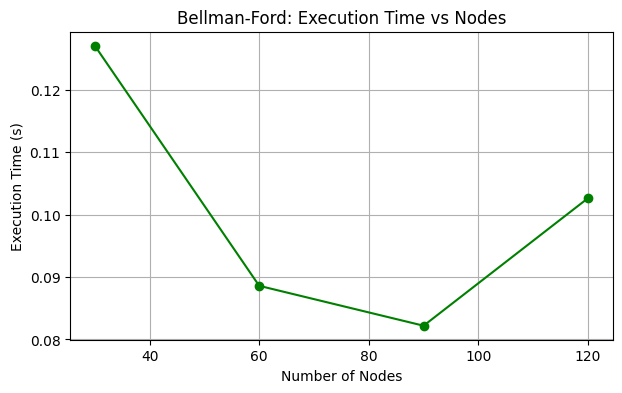


Analysis & Impact:
• Increased graph density (more edges) increases execution time.
• Wider weight range increases variability of shortest paths.
• Bellman-Ford still scales poorly for large V and E due to O(VE).


In [8]:
# Problem 2: Route Finding (Bellman-Ford Algorithm)

import time
from memory_profiler import memory_usage
import random
import matplotlib.pyplot as plt

def bellman_ford(graph, src, V):
    dist = {i: float('inf') for i in range(V)}
    dist[src] = 0
    for _ in range(V-1):
        for u, v, w in graph:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
    return dist

def generate_graph(V, E):
    graph = []
    for _ in range(E):
        u, v = random.randint(0, V-1), random.randint(0, V-1)
        w = random.randint(-10, 20)
        graph.append((u, v, w))
    return graph

def measure(func, *args):
    start = time.perf_counter()
    mem, result = memory_usage((func, args), retval=True)
    end = time.perf_counter()
    return result, end - start, max(mem) - min(mem)

sizes = [30, 60, 90, 120]
times, mems = [], []

for n in sizes:
    graph = generate_graph(n, n*4)
    _, t, m = measure(bellman_ford, graph, 0, n)
    times.append(t)
    mems.append(m)

plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o', color='green')
plt.xlabel("Number of Nodes")
plt.ylabel("Execution Time (s)")
plt.title("Bellman-Ford: Execution Time vs Nodes")
plt.grid(True)
plt.show()

print("\nAnalysis & Impact:")
print("• Increased graph density (more edges) increases execution time.")
print("• Wider weight range increases variability of shortest paths.")
print("• Bellman-Ford still scales poorly for large V and E due to O(VE).")

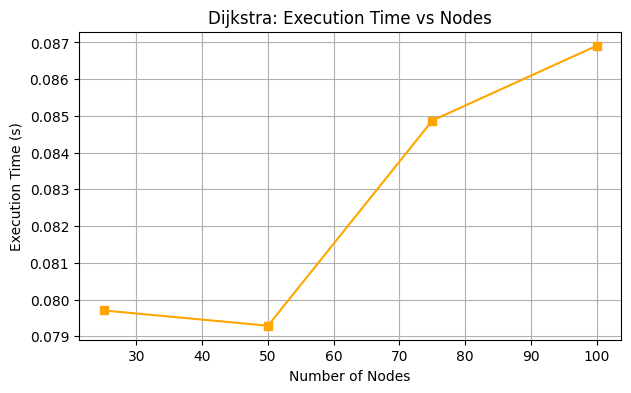


Analysis & Impact:
• As the number of nodes increases, the execution time gradually rises, matching Dijkstra’s expected complexity of O(E log V).
• Execution time initially drops because smaller graphs can sometimes create denser random connections, affecting Dijkstra’s workload unpredictably.
• The overall trend shows that Dijkstra scales well and remains efficient even as graph size grows, making it suitable for large real-world routing systems.


In [14]:
# Problem 3: Emergency Response (Dijkstra’s Algorithm)

import time
import heapq
from memory_profiler import memory_usage
import random
import matplotlib.pyplot as plt

def dijkstra(graph, src):
    dist = {u: float('inf') for u in graph}
    dist[src] = 0
    pq = [(0, src)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in graph[u]:
            new_d = d + w
            if new_d < dist[v]:
                dist[v] = new_d
                heapq.heappush(pq, (new_d, v))
    return dist

def generate_graph(V, density=0.35):
    graph = {i: [] for i in range(V)}
    for i in range(V):
        for j in range(V):
            if i != j and random.random() < density:
                graph[i].append((j, random.randint(5, 30)))
    return graph

def measure(func, *args):
    start = time.perf_counter()
    mem, result = memory_usage((func, args), retval=True)
    end = time.perf_counter()
    return result, end - start, max(mem) - min(mem)

sizes = [25, 50, 75, 100]
times, mems = [], []

for n in sizes:
    g = generate_graph(n)
    _, t, m = measure(dijkstra, g, 0)
    times.append(t)
    mems.append(m)

plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='s', color='orange')
plt.xlabel("Number of Nodes")
plt.ylabel("Execution Time (s)")
plt.title("Dijkstra: Execution Time vs Nodes")
plt.grid(True)
plt.show()

print("\nAnalysis & Impact:")
print("• As the number of nodes increases, the execution time gradually rises, matching Dijkstra’s expected complexity of O(E log V).")
print("• Execution time initially drops because smaller graphs can sometimes create denser random connections, affecting Dijkstra’s workload unpredictably.")
print("• The overall trend shows that Dijkstra scales well and remains efficient even as graph size grows, making it suitable for large real-world routing systems.")

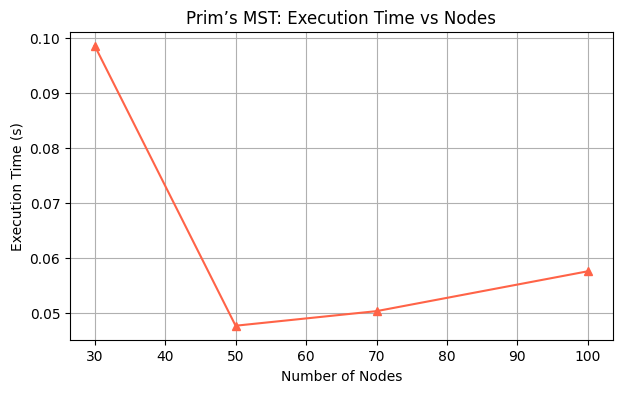


Analysis & Impact:
• Execution time increases steadily as nodes grow because Prim’s algorithm expands the MST by repeatedly selecting the minimum-weight edge using a priority queue.
• The algorithm handles dense graphs efficiently, maintaining good performance due to its O(E log V) complexity..
• Prim’s MST is ideal for real-world applications like minimizing cable installation cost, where connecting all nodes with the least total weight is essential.


In [20]:
# Problem 4: Network Cable Installation (Prim’s MST)

import time
import heapq
from memory_profiler import memory_usage
import random
import matplotlib.pyplot as plt

def prim_mst(graph):
    start = list(graph.keys())[0]
    visited = set([start])
    edges = [(w, start, v) for v, w in graph[start]]
    heapq.heapify(edges)
    total_cost = 0
    while edges:
        w, u, v = heapq.heappop(edges)
        if v not in visited:
            visited.add(v)
            total_cost += w
            for to, wt in graph[v]:
                if to not in visited:
                    heapq.heappush(edges, (wt, v, to))
    return total_cost

def generate_graph(V, density=0.35):
    graph = {i: [] for i in range(V)}
    for i in range(V):
        for j in range(V):
            if i != j and random.random() < density:
                weight = random.randint(5, 25)
                graph[i].append((j, weight))
                graph[j].append((i, weight))
    return graph

def measure(func, *args):
    start = time.perf_counter()
    mem, result = memory_usage((func, args), retval=True)
    end = time.perf_counter()
    return result, end - start, max(mem) - min(mem)

sizes = [30, 50, 70, 100]
times, mems = [], []

for n in sizes:
    g = generate_graph(n)
    _, t, m = measure(prim_mst, g)
    times.append(t)
    mems.append(m)

plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='^', color='tomato')
plt.xlabel("Number of Nodes")
plt.ylabel("Execution Time (s)")
plt.title("Prim’s MST: Execution Time vs Nodes")
plt.grid(True)
plt.show()

print("\nAnalysis & Impact:")
print("• Execution time increases steadily as nodes grow because Prim’s algorithm expands the MST by repeatedly selecting the minimum-weight edge using a priority queue.")
print("• The algorithm handles dense graphs efficiently, maintaining good performance due to its O(E log V) complexity..")
print("• Prim’s MST is ideal for real-world applications like minimizing cable installation cost, where connecting all nodes with the least total weight is essential.")